# Logistic Regression: Student Pass/Fail Prediction

## Problem
Predict whether a student will **pass (1)** or **fail (0)** from study hours, attendance and previous score. This is a **classification** problem, because the answer is a category and not a number.

## Objective
Learn how logistic regression turns inputs into a pass probability, and evaluate it with accuracy, a confusion matrix, precision and recall.

**Dataset:** `data/student_pass_fail.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real students.

| Column | Meaning |
|--------|---------|
| `study_hours` | Daily study hours (0 to 10) |
| `attendance_pct` | Attendance percentage (50 to 100) |
| `previous_score` | Score in the previous exam (20 to 100) |
| `passed` | 1 = passed, 0 = failed (target) |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load the Dataset

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("student_pass_fail.csv"))
print("Shape:", df.shape, "| Missing values:", df.isna().sum().sum())
print("Pass rate:", round(df["passed"].mean() * 100, 1), "%")
df.head()

Shape: (300, 4) | Missing values: 0
Pass rate: 45.7 %


,study_hours,attendance_pct,previous_score,passed
0,3.9,87,53,1
1,2.7,95,61,1
2,5.2,64,41,0
3,3.1,56,86,0
4,5.6,98,77,1


## 3. Explore: Do Passing Students Study More?

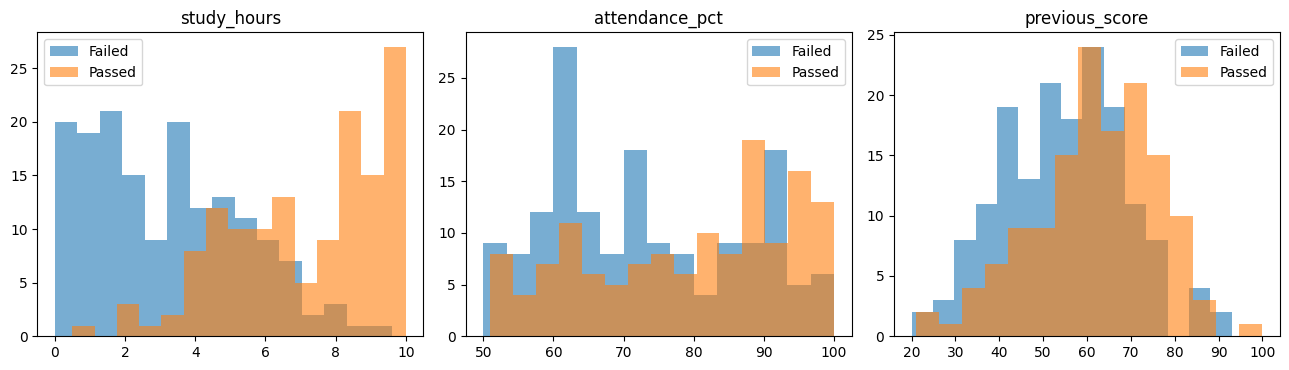

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col in zip(axes, ["study_hours", "attendance_pct", "previous_score"]):
    ax.hist(df[df["passed"] == 0][col], bins=15, alpha=0.6, label="Failed")
    ax.hist(df[df["passed"] == 1][col], bins=15, alpha=0.6, label="Passed")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

Passing students tend to study more hours, attend more classes and have higher previous scores. The groups overlap, so no single feature separates them perfectly, which is realistic.

## 4. Part A: One Feature and the Sigmoid Curve

Logistic regression does not draw a straight line. It draws an **S-shaped sigmoid curve** that turns any input into a probability between 0 and 1. If the probability is above **0.5**, the prediction is Pass.

First we use only `study_hours`, so we can see the curve.

Accuracy using study hours only: 0.85


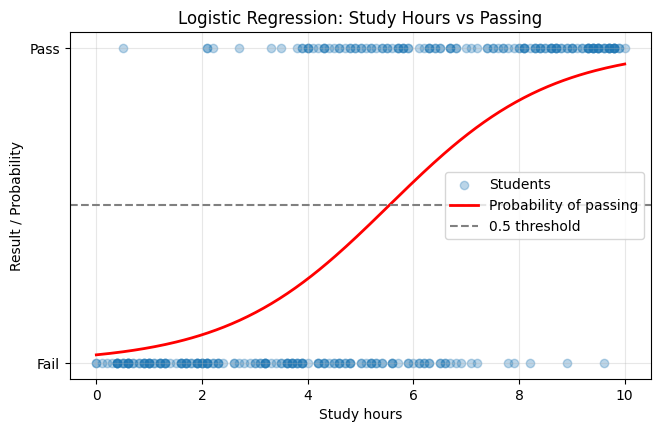

In [5]:
X1 = df[["study_hours"]]
y = df["passed"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42, stratify=y)
single = LogisticRegression().fit(X1_train, y1_train)
print("Accuracy using study hours only:", round(accuracy_score(y1_test, single.predict(X1_test)), 3))

hours = pd.DataFrame({"study_hours": np.linspace(0, 10, 200)})

plt.figure(figsize=(7.5, 4.5))
plt.scatter(df["study_hours"], df["passed"], alpha=0.3, label="Students")
plt.plot(hours, single.predict_proba(hours)[:, 1], color="red", linewidth=2, label="Probability of passing")
plt.axhline(0.5, color="gray", linestyle="--", label="0.5 threshold")
plt.yticks([0, 1], ["Fail", "Pass"])
plt.title("Logistic Regression: Study Hours vs Passing")
plt.xlabel("Study hours")
plt.ylabel("Result / Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Part B: Use All Three Features

Real outcomes depend on more than one factor, so we now train on all three. We use `stratify=y` so that the train and test sets keep the same pass/fail balance.

In [6]:
features = ["study_hours", "attendance_pct", "previous_score"]
X = df[features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy using all three features:", round(accuracy_score(y_test, pred), 3))

Accuracy using all three features: 0.883


## 6. Evaluate Beyond Accuracy

Accuracy alone can hide problems. The **confusion matrix** shows exactly what the model got right and wrong:

- **True Negative:** predicted Fail, actually Failed.
- **False Positive:** predicted Pass, actually Failed.
- **False Negative:** predicted Fail, actually Passed.
- **True Positive:** predicted Pass, actually Passed.

**Precision** = of the students predicted to pass, how many really passed. **Recall** = of the students who really passed, how many did we find.

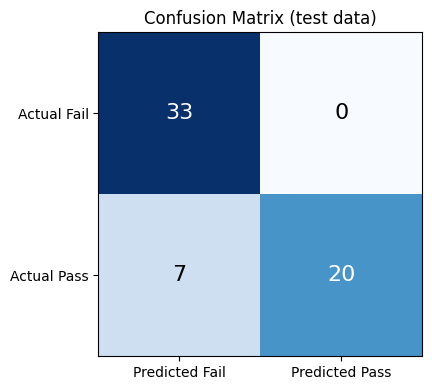

              precision    recall  f1-score   support

        Fail       0.82      1.00      0.90        33
        Pass       1.00      0.74      0.85        27

    accuracy                           0.88        60
   macro avg       0.91      0.87      0.88        60
weighted avg       0.90      0.88      0.88        60



In [7]:
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["Predicted Fail", "Predicted Pass"])
ax.set_yticks([0, 1], ["Actual Fail", "Actual Pass"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Confusion Matrix (test data)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, target_names=["Fail", "Pass"]))

## 7. What Does Each Feature Contribute?

The exponent of a coefficient is an **odds ratio**: how much the odds of passing are multiplied when that feature increases by one unit (other features unchanged).

In [8]:
odds = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0].round(3),
    "odds_ratio": np.exp(model.coef_[0]).round(2),
})
odds

,feature,coefficient,odds_ratio
0,study_hours,0.996,2.71
1,attendance_pct,0.083,1.09
2,previous_score,0.085,1.09


For example, each extra **study hour** multiplies the odds of passing by about **2.7**, while each extra attendance percentage point or previous-score point raises the odds by about **9%**. Study hours matter most per unit.

## 8. Predict for a New Student

In [9]:
student = pd.DataFrame([[6, 85, 65]], columns=features)   # 6 hours, 85% attendance, previous score 65
prob_fail, prob_pass = model.predict_proba(student)[0]

print(f"Probability of failing : {prob_fail:.1%}")
print(f"Probability of passing : {prob_pass:.1%}")
print("Prediction:", "Pass" if model.predict(student)[0] == 1 else "Fail")

Probability of failing : 13.0%
Probability of passing : 87.0%
Prediction: Pass


## Conclusion

- Using **all three features**, the model reaches **88% accuracy** on unseen students, better than study hours alone (85%).
- **Precision is 100%**: every student predicted to pass really passed.
- **Recall for Pass is about 74%**: the model missed some students who actually passed. It is cautious and tends to predict Fail when unsure.
- If missing a passing student is costly, the 0.5 threshold can be lowered to catch more of them, at the price of more false alarms.
- Study hours have the strongest effect per unit, but attendance and previous score also matter.